In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re

file_path = "/Users/RaulPerez/Documents/Projects/cumulative_report/data/raw/country_year_final_panel_full.csv"
df = pd.read_csv(file_path)

rule_prefixes = (
    "C_", "I_", "P_",
    "IM_", "GOV_", "PRESS_",
    "APPEAL_", "EXEMPTION_", "LAWSUIT_", "REG_"
)

value_cols = [c for c in df.columns if str(c).startswith(rule_prefixes)]

id_cols = [c for c in df.columns if c in ["COUNTRY", "year", "iso3"] or str(c).startswith("Unnamed")]

X_presence = (df[value_cols].fillna(0) != 0).astype(int)

print("Dataset shape:", df.shape)
print("Number of rule columns:", len(value_cols))
print("First 10 rule columns:", value_cols[:10])

Dataset shape: (8580, 189)
Number of rule columns: 136
First 10 rule columns: ['APPEAL_NONREG', 'APPEAL_NONREG_CRISIS', 'APPEAL_REG', 'APPEAL_REG_CRISIS', 'C_DISINFO_GEN', 'C_DISINFO_GEN_CRISIS', 'C_DISINFO_GEN_DIGI', 'C_DISINFO_ICCPR', 'C_DISINFO_ICCPR_CRISIS', 'C_DISINFO_ICCPR_DIGI']


In [2]:
def classify_scope(col):
    tokens = str(col).split("_")
    family = tokens[0]

    out = {
        "column": col,
        "family": family,
        "scope_group": None,
        "actor_group": None,
        "topic": None,
        "basis": None,
        "condition": "standard",
        "detail": None,
    }

    if family in {"C", "I", "P"}:
        out["scope_group"] = "substantive_regulation"
    elif family in {"IM", "GOV", "PRESS"}:
        out["scope_group"] = "governance_design"
    elif family in {"APPEAL", "EXEMPTION", "LAWSUIT", "REG"}:
        out["scope_group"] = "procedural_protection"
    else:
        out["scope_group"] = "other"

    actor_map = {
        "C": "citizens",
        "I": "internet/platforms",
        "P": "press",
        "IM": "intermediary_design",
        "GOV": "government_design",
        "PRESS": "press_design",
        "APPEAL": "procedural",
        "EXEMPTION": "procedural",
        "LAWSUIT": "procedural",
        "REG": "procedural",
    }
    out["actor_group"] = actor_map.get(family, "other")

    if "NON-ICCPR" in tokens:
        out["basis"] = "NON-ICCPR"
    elif "ICCPR" in tokens:
        out["basis"] = "ICCPR"
    elif "GEN" in tokens:
        out["basis"] = "GEN"

    conds = [t for t in tokens if t in {"CRISIS", "DIGI", "GOVOFF"}]
    if conds:
        out["condition"] = "|".join(conds)

    if family in {"C", "I", "P"}:
        if "DISINFO" in tokens:
            out["topic"] = "disinformation"
        elif "MISINFO" in tokens:
            out["topic"] = "misinformation"
        elif "MALINFO" in tokens:
            out["topic"] = "malinformation"
        elif "EXPRESS" in tokens:
            out["topic"] = "expression"
    elif family == "IM":
        out["topic"] = "intermediary_obligation"
        out["detail"] = "_".join(tokens[1:])
    elif family == "GOV":
        out["topic"] = "government_power"
        out["detail"] = "_".join(tokens[1:])
    elif family == "PRESS":
        out["topic"] = "press_obligation"
        out["detail"] = "_".join(tokens[1:])
    elif family == "APPEAL":
        out["topic"] = "appeal"
        out["detail"] = "_".join(tokens[1:])
    elif family == "EXEMPTION":
        out["topic"] = "exemption"
        out["detail"] = "_".join(tokens[1:])
    elif family == "LAWSUIT":
        out["topic"] = "lawsuit"
        out["detail"] = "_".join(tokens[1:])
    elif family == "REG":
        out["topic"] = "regulation"
        out["detail"] = "_".join(tokens[1:])

    return out

col_dict = pd.DataFrame([classify_scope(c) for c in value_cols])

print(col_dict.head())

                 column  family             scope_group actor_group  \
0         APPEAL_NONREG  APPEAL   procedural_protection  procedural   
1  APPEAL_NONREG_CRISIS  APPEAL   procedural_protection  procedural   
2            APPEAL_REG  APPEAL   procedural_protection  procedural   
3     APPEAL_REG_CRISIS  APPEAL   procedural_protection  procedural   
4         C_DISINFO_GEN       C  substantive_regulation    citizens   

            topic basis condition         detail  
0          appeal  None  standard         NONREG  
1          appeal  None    CRISIS  NONREG_CRISIS  
2          appeal  None  standard            REG  
3          appeal  None    CRISIS     REG_CRISIS  
4  disinformation   GEN  standard           None  


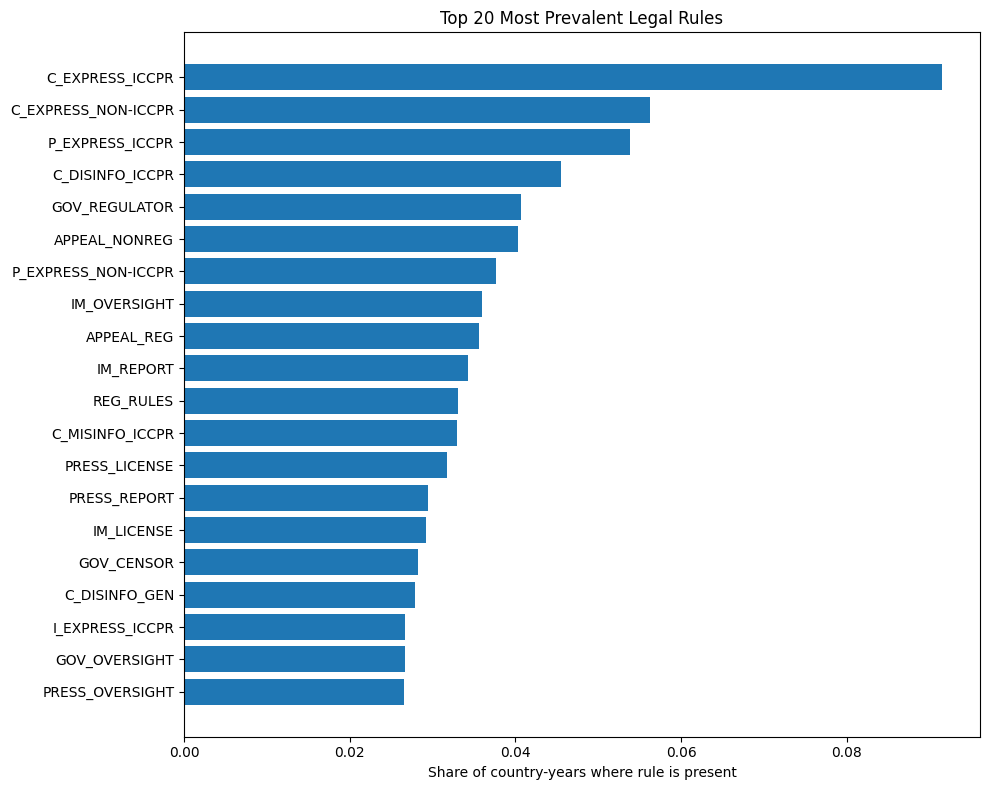

,column,prevalence
103,PRESS_OVERSIGHT,0.026573
40,GOV_OVERSIGHT,0.026690
77,I_EXPRESS_ICCPR,0.026690
4,C_DISINFO_GEN,0.027855
36,GOV_CENSOR,0.028205
58,IM_LICENSE,0.029254
105,PRESS_REPORT,0.029487
101,PRESS_LICENSE,0.031702
26,C_MISINFO_ICCPR,0.032984
134,REG_RULES,0.033100


In [3]:
presence_summary = pd.DataFrame({
    "column": value_cols,
    "prevalence": X_presence.mean().values
})

top_n = 20

fig1_df = (
    presence_summary
    .sort_values("prevalence", ascending=False)
    .head(top_n)
    .sort_values("prevalence", ascending=True)
)

plt.figure(figsize=(10, 8))
plt.barh(fig1_df["column"], fig1_df["prevalence"])
plt.xlabel("Share of country-years where rule is present")
plt.title("Top 20 Most Prevalent Legal Rules")
plt.tight_layout()
plt.show()

fig1_df

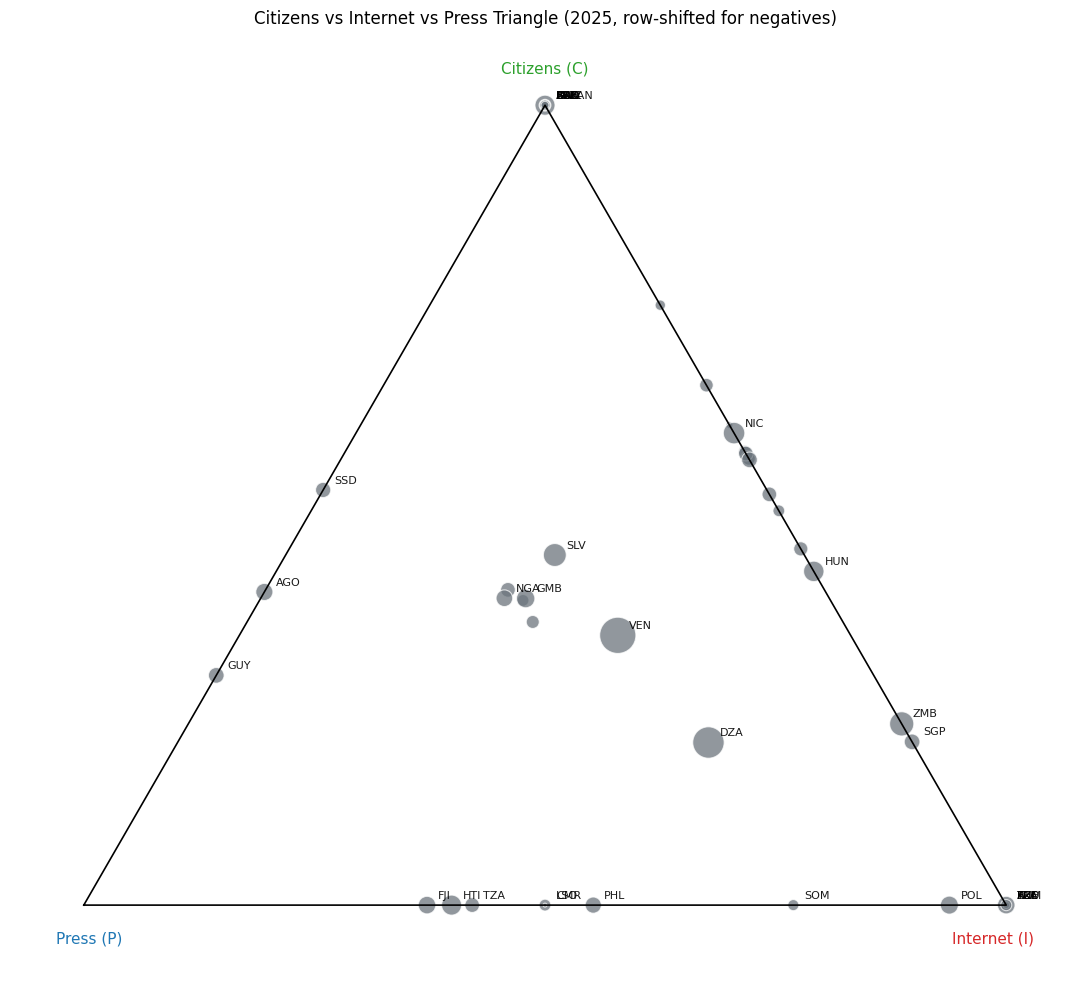

,COUNTRY,iso3,weighted_de_jure_C,weighted_de_jure_I,weighted_de_jure_P,shift_applied,C_share,I_share,P_share,legal_rule_count_total
8183,Venezuela,VEN,0.580645,0.706349,0.434641,0.000000,0.337264,0.410278,0.252458,85
395,Algeria,DZA,0.235450,0.666667,0.256173,0.000000,0.203274,0.575561,0.221165,64
8447,Zambia,ZMB,-0.074074,0.666667,-0.380952,0.380952,0.226563,0.773437,0.000000,38
2243,El Salvador,SLV,1.000000,0.666667,0.618056,0.000000,0.437690,0.291793,0.270517,34
5147,Nicaragua,NIC,0.785185,0.545455,0.000000,0.000000,0.590081,0.409919,0.000000,30
3563,Hungary,HUN,0.477273,0.666667,0.000000,0.000000,0.417219,0.582781,0.000000,27
3299,Haiti,HTI,0.000000,0.400000,0.603175,0.000000,0.000000,0.398734,0.601266,26
923,Bangladesh,BGD,0.423611,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,26
7523,The Gambia,GMB,0.888889,0.666667,0.763889,0.000000,0.383234,0.287425,0.329341,22
5939,Poland,POL,-1.000000,0.691358,-0.888889,1.000000,0.000000,0.938356,0.061644,21


In [4]:
plot_year = 2025

triangle_df = (
    df.loc[df["year"] == plot_year, [
        "COUNTRY",
        "iso3",
        "weighted_de_jure_C",
        "weighted_de_jure_I",
        "weighted_de_jure_P",
        "legal_rule_count_total"
    ]]
    .dropna()
    .copy()
)

triangle_df = triangle_df[
    (triangle_df["weighted_de_jure_C"] != 0) |
    (triangle_df["weighted_de_jure_I"] != 0) |
    (triangle_df["weighted_de_jure_P"] != 0)
].copy()

# Shift negative values upward within each country before converting
row_min = triangle_df[["weighted_de_jure_C", "weighted_de_jure_I", "weighted_de_jure_P"]].min(axis=1)
shift = np.where(row_min < 0, -row_min, 0)

triangle_df["C_shifted"] = triangle_df["weighted_de_jure_C"] + shift
triangle_df["I_shifted"] = triangle_df["weighted_de_jure_I"] + shift
triangle_df["P_shifted"] = triangle_df["weighted_de_jure_P"] + shift
triangle_df["shift_applied"] = shift

triangle_df = triangle_df[
    triangle_df[["C_shifted", "I_shifted", "P_shifted"]].sum(axis=1) > 0
].copy()

triangle_df["C_share"] = triangle_df["C_shifted"] / triangle_df[["C_shifted", "I_shifted", "P_shifted"]].sum(axis=1)
triangle_df["I_share"] = triangle_df["I_shifted"] / triangle_df[["C_shifted", "I_shifted", "P_shifted"]].sum(axis=1)
triangle_df["P_share"] = triangle_df["P_shifted"] / triangle_df[["C_shifted", "I_shifted", "P_shifted"]].sum(axis=1)

# P = left vertex, I = right vertex, C = top vertex
triangle_df["x"] = triangle_df["I_share"] + 0.5 * triangle_df["C_share"]
triangle_df["y"] = (np.sqrt(3) / 2) * triangle_df["C_share"]
triangle_df["bubble_size"] = triangle_df["legal_rule_count_total"] * 8

label_df = pd.concat([
    triangle_df.nlargest(12, "legal_rule_count_total"),
    triangle_df.nlargest(10, "C_share"),
    triangle_df.nlargest(10, "I_share"),
    triangle_df.nlargest(10, "P_share")
]).drop_duplicates(subset="iso3")

triangle_outline = np.array([
    [0, 0],
    [1, 0],
    [0.5, np.sqrt(3) / 2],
    [0, 0]
])

plt.figure(figsize=(11, 10))
plt.plot(triangle_outline[:, 0], triangle_outline[:, 1], color="black", linewidth=1.2)
plt.scatter(
    triangle_df["x"],
    triangle_df["y"],
    s=triangle_df["bubble_size"],
    color="#6c757d",
    alpha=0.75,
    edgecolor="white",
    linewidth=0.8
)

for _, row in label_df.iterrows():
    plt.text(
        row["x"] + 0.012,
        row["y"] + 0.008,
        row["iso3"],
        fontsize=8,
        alpha=0.9
    )

plt.text(-0.03, -0.04, "Press (P)", color="#1f77b4", fontsize=11, ha="left")
plt.text(1.03, -0.04, "Internet (I)", color="#d62728", fontsize=11, ha="right")
plt.text(0.5, np.sqrt(3) / 2 + 0.035, "Citizens (C)", color="#2ca02c", fontsize=11, ha="center")

plt.xlim(-0.08, 1.08)
plt.ylim(-0.08, np.sqrt(3) / 2 + 0.08)
plt.axis("off")
plt.title("Citizens vs Internet vs Press Triangle (2025, row-shifted for negatives)")
plt.tight_layout()
plt.show()

triangle_df[[
    "COUNTRY",
    "iso3",
    "weighted_de_jure_C",
    "weighted_de_jure_I",
    "weighted_de_jure_P",
    "shift_applied",
    "C_share",
    "I_share",
    "P_share",
    "legal_rule_count_total"
]].sort_values("legal_rule_count_total", ascending=False)


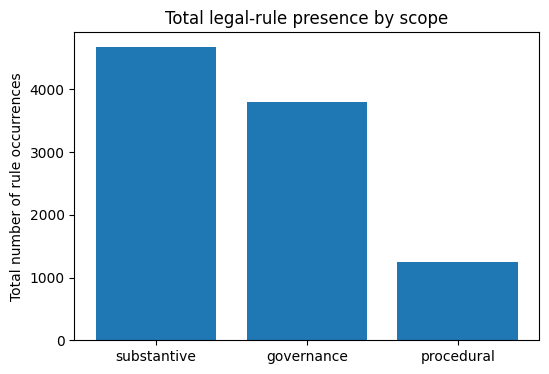

,group,total_presence
0,substantive,4676
1,governance,3797
2,procedural,1253


In [5]:
groups = {
    "substantive": [c for c in value_cols if c.startswith(("C_", "I_", "P_"))],
    "governance": [c for c in value_cols if c.startswith(("IM_", "GOV_", "PRESS_"))],
    "procedural": [c for c in value_cols if c.startswith(("APPEAL_", "EXEMPTION_", "LAWSUIT_", "REG_"))],
}

total_summary = []

for name, cols in groups.items():
    total_summary.append({
        "group": name,
        "total_presence": X_presence[cols].sum().sum()
    })

total_df = pd.DataFrame(total_summary)

plt.figure(figsize=(6, 4))
plt.bar(total_df["group"], total_df["total_presence"])
plt.ylabel("Total number of rule occurrences")
plt.title("Total legal-rule presence by scope")
plt.show()

total_df

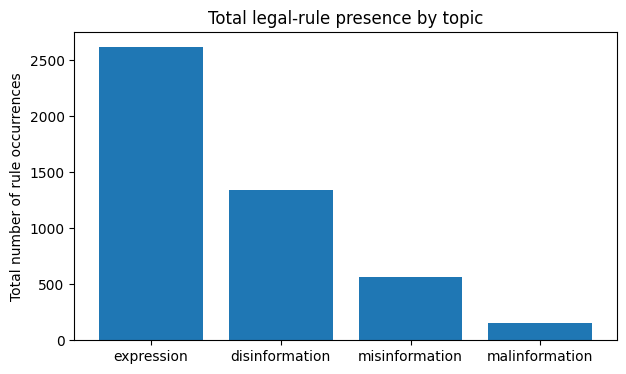

,topic,avg_prevalence,total_presence
0,expression,0.016059,2618
1,disinformation,0.005802,1344
2,misinformation,0.002426,562
3,malinformation,0.001968,152


In [6]:
topic_groups = {
    "expression": [c for c in value_cols if "_EXPRESS_" in c],
    "disinformation": [c for c in value_cols if "_DISINFO_" in c],
    "misinformation": [c for c in value_cols if "_MISINFO_" in c],
    "malinformation": [c for c in value_cols if "_MALINFO_" in c],
}

topic_summary = []

for topic, cols in topic_groups.items():
    topic_summary.append({
        "topic": topic,
        "avg_prevalence": X_presence[cols].mean().mean() if len(cols) > 0 else np.nan,
        "total_presence": X_presence[cols].sum().sum() if len(cols) > 0 else 0
    })

topic_df = pd.DataFrame(topic_summary)

plt.figure(figsize=(7, 4))
plt.bar(topic_df["topic"], topic_df["total_presence"])
plt.ylabel("Total number of rule occurrences")
plt.title("Total legal-rule presence by topic")
plt.show()

topic_df

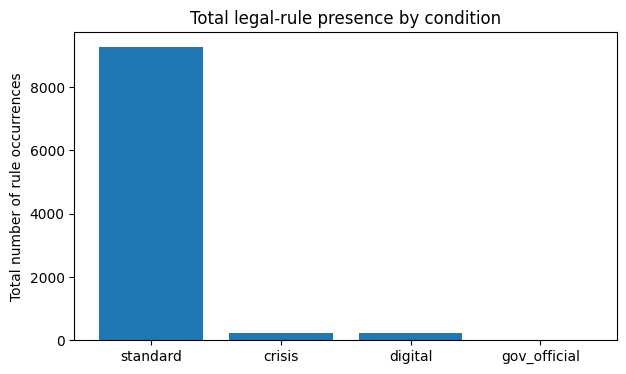

,condition,avg_prevalence,total_presence
0,standard,0.020008,9270
1,crisis,0.000509,236
2,digital,0.000950,220
3,gov_official,0.000000,0


In [7]:
condition_groups = {
    "standard": [c for c in value_cols if not any(tag in c for tag in ["_CRISIS", "_DIGI", "_GOVOFF"])],
    "crisis": [c for c in value_cols if "_CRISIS" in c],
    "digital": [c for c in value_cols if "_DIGI" in c],
    "gov_official": [c for c in value_cols if "_GOVOFF" in c],
}

condition_summary = []

for cond, cols in condition_groups.items():
    if len(cols) == 0:
        continue

    condition_summary.append({
        "condition": cond,
        "avg_prevalence": X_presence[cols].mean().mean(),
        "total_presence": X_presence[cols].sum().sum()
    })

condition_df = pd.DataFrame(condition_summary)

plt.figure(figsize=(7, 4))
plt.bar(condition_df["condition"], condition_df["total_presence"])
plt.ylabel("Total number of rule occurrences")
plt.title("Total legal-rule presence by condition")
plt.show()

condition_df

In [8]:
std_cols = [c for c in value_cols if not any(tag in c for tag in ["_CRISIS", "_DIGI", "_GOVOFF"])]

X_std = X_presence[std_cols].copy()

min_prev = 0.005
keep_cols = X_std.columns[X_std.mean() >= min_prev]
X_std = X_std[keep_cols]

print("Standard-rule columns before filtering:", len(std_cols))
print("Columns kept after rarity filter:", len(keep_cols))

cooccur = X_std.T.dot(X_std)

np.fill_diagonal(cooccur.values, 0)

cooccur_long = (
    cooccur.stack()
    .reset_index()
)
cooccur_long.columns = ["rule_1", "rule_2", "cooccur"]

cooccur_long = cooccur_long[cooccur_long["rule_1"] < cooccur_long["rule_2"]]

top_pairs = cooccur_long.sort_values("cooccur", ascending=False).head(60)

top_pairs.head(60)

Standard-rule columns before filtering: 54
Columns kept after rarity filter: 44


,rule_1,rule_2,cooccur
226,C_EXPRESS_ICCPR,C_EXPRESS_NON-ICCPR,462
260,C_EXPRESS_ICCPR,P_EXPRESS_ICCPR,412
137,C_DISINFO_ICCPR,C_EXPRESS_ICCPR,365
304,C_EXPRESS_NON-ICCPR,P_EXPRESS_ICCPR,292
1801,P_EXPRESS_ICCPR,P_EXPRESS_NON-ICCPR,275
172,C_DISINFO_ICCPR,P_EXPRESS_ICCPR,270
261,C_EXPRESS_ICCPR,P_EXPRESS_NON-ICCPR,263
138,C_DISINFO_ICCPR,C_EXPRESS_NON-ICCPR,260
233,C_EXPRESS_ICCPR,GOV_REGULATOR,254
305,C_EXPRESS_NON-ICCPR,P_EXPRESS_NON-ICCPR,253


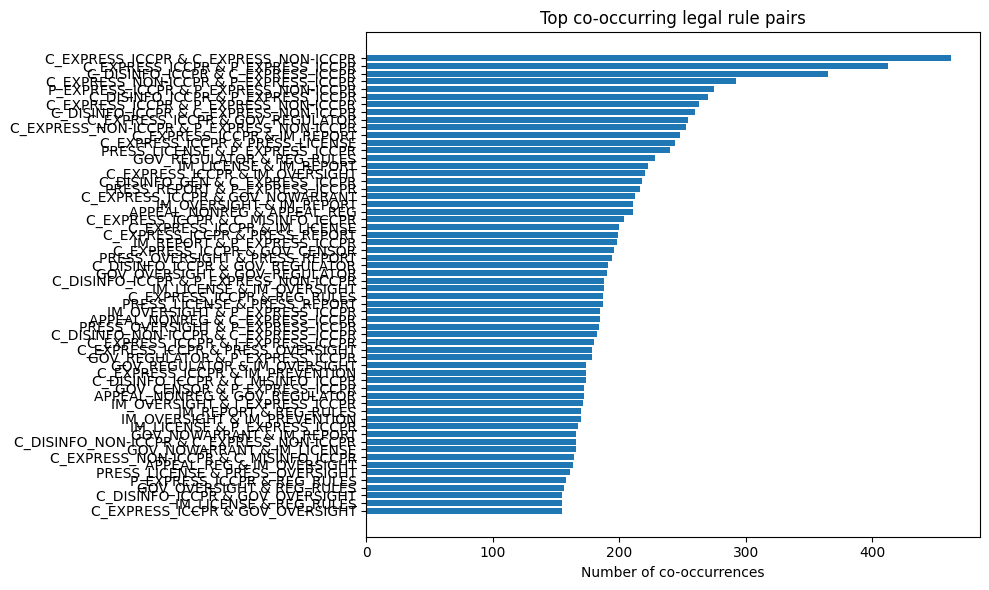

In [9]:
plt.figure(figsize=(10, 6))
plt.barh(
    top_pairs["rule_1"] + " & " + top_pairs["rule_2"],
    top_pairs["cooccur"]
)
plt.xlabel("Number of co-occurrences")
plt.title("Top co-occurring legal rule pairs")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

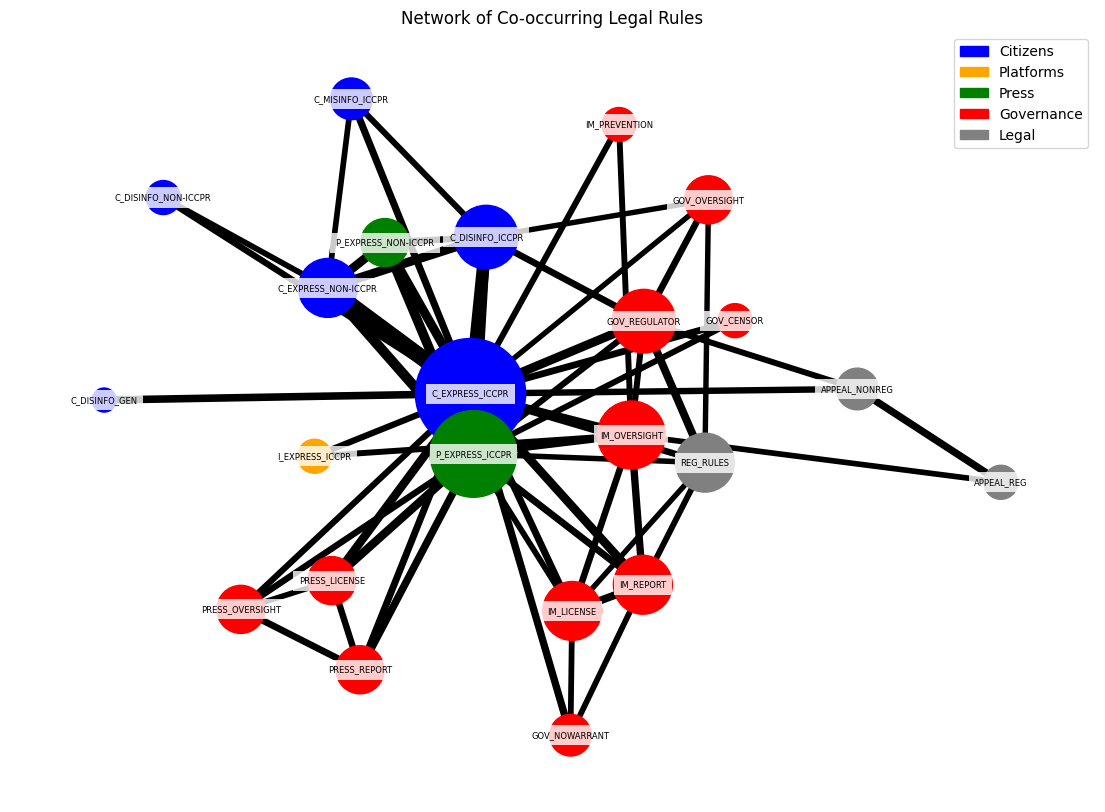

In [10]:
import networkx as nx
import matplotlib.patches as mpatches

network_df = cooccur_long.sort_values("cooccur", ascending=False).head(60)

G = nx.Graph()

for _, row in network_df.iterrows():
    G.add_edge(row["rule_1"], row["rule_2"], weight=row["cooccur"])

edge_widths = [G[u][v]["weight"] / 40 for u, v in G.edges()]

color_map = []

for node in G.nodes():
    if node.startswith("C_"):
        color_map.append("blue")
    elif node.startswith("I_"):
        color_map.append("orange")
    elif node.startswith("P_"):
        color_map.append("green")
    elif node.startswith(("IM_", "GOV_", "PRESS_")):
        color_map.append("red")
    else:
        color_map.append("gray")

degree = dict(G.degree())
node_sizes = [degree[n] * 300 for n in G.nodes()]

plt.figure(figsize=(14, 10))
pos = nx.spring_layout(G, seed=42, k=2.2, iterations=300)

nx.draw_networkx_nodes(G, pos, node_size=node_sizes, node_color=color_map)
nx.draw_networkx_edges(G, pos, width=edge_widths)
nx.draw_networkx_labels(
    G,
    pos,
    font_size=6,
    bbox=dict(facecolor="white", edgecolor="none", alpha=0.8)
)

legend_handles = [
    mpatches.Patch(color="blue", label="Citizens"),
    mpatches.Patch(color="orange", label="Platforms"),
    mpatches.Patch(color="green", label="Press"),
    mpatches.Patch(color="red", label="Governance"),
    mpatches.Patch(color="gray", label="Legal"),
]

plt.legend(handles=legend_handles, loc="upper right")
plt.title("Network of Co-occurring Legal Rules")
plt.axis("off")
plt.show()

In [11]:
press_cols = [c for c in value_cols if c.startswith("P_")]
internet_cols = [c for c in value_cols if c.startswith("I_")]

print("Press columns:", len(press_cols))
print("Internet/platform columns:", len(internet_cols))
print("\nFirst press columns:", press_cols[:10])
print("\nFirst internet columns:", internet_cols[:10])

Press columns: 27
Internet/platform columns: 27

First press columns: ['P_DISINFO_GEN', 'P_DISINFO_GEN_CRISIS', 'P_DISINFO_GEN_DIGI', 'P_DISINFO_ICCPR', 'P_DISINFO_ICCPR_CRISIS', 'P_DISINFO_ICCPR_DIGI', 'P_DISINFO_NON-ICCPR', 'P_DISINFO_NON-ICCPR_CRISIS', 'P_DISINFO_NON-ICCPR_DIGI', 'P_EXPRESS_ICCPR']

First internet columns: ['I_DISINFO_GEN', 'I_DISINFO_GEN_CRISIS', 'I_DISINFO_GEN_DIGI', 'I_DISINFO_ICCPR', 'I_DISINFO_ICCPR_CRISIS', 'I_DISINFO_ICCPR_DIGI', 'I_DISINFO_NON-ICCPR', 'I_DISINFO_NON-ICCPR_CRISIS', 'I_DISINFO_NON-ICCPR_DIGI', 'I_EXPRESS_ICCPR']


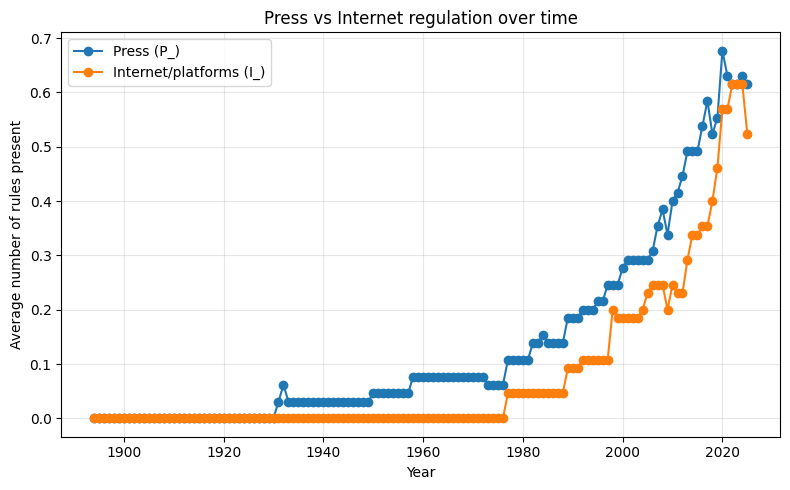

In [12]:
yearly_press_i = pd.DataFrame({
    "year": df["year"],
    "press_presence": X_presence[press_cols].sum(axis=1),
    "internet_presence": X_presence[internet_cols].sum(axis=1)
})

yearly_press_i_avg = (
    yearly_press_i.groupby("year")[["press_presence", "internet_presence"]]
    .mean()
    .reset_index()
)

plt.figure(figsize=(8, 5))
plt.plot(yearly_press_i_avg["year"], yearly_press_i_avg["press_presence"], marker="o", label="Press (P_)")
plt.plot(yearly_press_i_avg["year"], yearly_press_i_avg["internet_presence"], marker="o", label="Internet/platforms (I_)")
plt.xlabel("Year")
plt.ylabel("Average number of rules present")
plt.title("Press vs Internet regulation over time")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [13]:
press_gov_cols = [c for c in value_cols if c.startswith("PRESS_")]
im_cols = [c for c in value_cols if c.startswith("IM_")]

print("Press governance columns:", len(press_gov_cols))
print("Intermediary governance columns:", len(im_cols))
print("\nFirst PRESS_ columns:", press_gov_cols[:10])
print("\nFirst IM_ columns:", im_cols[:10])

Press governance columns: 10
Intermediary governance columns: 22

First PRESS_ columns: ['PRESS_CORRECT', 'PRESS_CORRECT_CRISIS', 'PRESS_FUNDING', 'PRESS_FUNDING_CRISIS', 'PRESS_LICENSE', 'PRESS_LICENSE_CRISIS', 'PRESS_OVERSIGHT', 'PRESS_OVERSIGHT_CRISIS', 'PRESS_REPORT', 'PRESS_REPORT_CRISIS']

First IM_ columns: ['IM_CORRECT', 'IM_CORRECT_CRISIS', 'IM_DAILY', 'IM_DAILY_CRISIS', 'IM_DATA', 'IM_DATA_CRISIS', 'IM_DEPLATFORM', 'IM_DEPLATFORM_CRISIS', 'IM_EMERGENCY', 'IM_EMERGENCY_CRISIS']


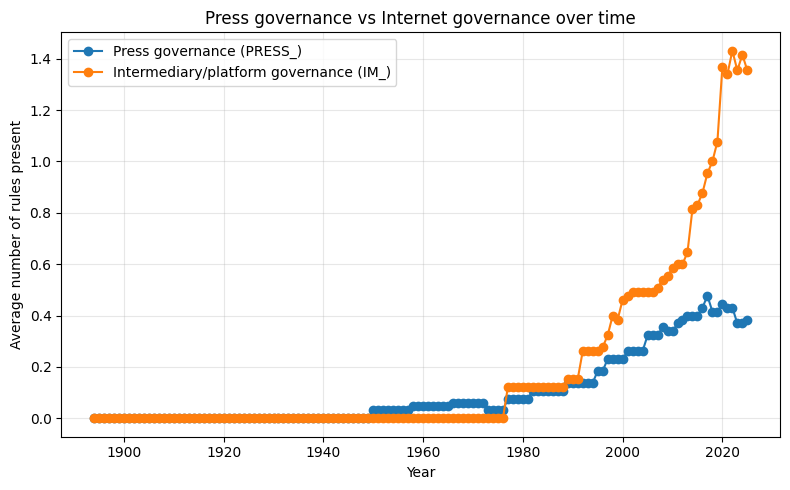

In [14]:
yearly_gov = pd.DataFrame({
    "year": df["year"],
    "press_governance_presence": X_presence[press_gov_cols].sum(axis=1),
    "intermediary_presence": X_presence[im_cols].sum(axis=1)
})

yearly_gov_avg = (
    yearly_gov.groupby("year")[["press_governance_presence", "intermediary_presence"]]
    .mean()
    .reset_index()
)

plt.figure(figsize=(8, 5))
plt.plot(yearly_gov_avg["year"], yearly_gov_avg["press_governance_presence"], marker="o", label="Press governance (PRESS_)")
plt.plot(yearly_gov_avg["year"], yearly_gov_avg["intermediary_presence"], marker="o", label="Intermediary/platform governance (IM_)")
plt.xlabel("Year")
plt.ylabel("Average number of rules present")
plt.title("Press governance vs Internet governance over time")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [15]:
def plot_rule_counts_by_year(df, X_presence, family_cols, title):
    yearly_rule_counts = (
        pd.concat([df[["year"]], X_presence[family_cols]], axis=1)
        .groupby("year")[family_cols]
        .sum()
        .reset_index()
    )

    family_cols = [c for c in family_cols if yearly_rule_counts[c].max() >= 3]

    plt.figure(figsize=(12, 7))

    for col in family_cols:
        plt.plot(
            yearly_rule_counts["year"],
            yearly_rule_counts[col],
            linewidth=1.8,
            alpha=0.9,
            label=col
        )

    plt.xlabel("Year")
    plt.ylabel("Number of countries with rule present")
    plt.title(title)
    plt.grid(True, alpha=0.3)
    plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
    plt.tight_layout()
    plt.show()

    return yearly_rule_counts

In [16]:
social_press_cols = press_cols + internet_cols + press_gov_cols + im_cols
selected_years = [1990, 1995, 2000, 2005, 2010, 2015, 2020, 2025]

In [17]:
def top_rules_for_year(df, X_presence, cols, year, top_n=5):
    year_mask = df["year"] == year
    counts = X_presence.loc[year_mask, cols].sum().sort_values(ascending=False).head(top_n)
    return counts.reset_index().rename(columns={"index": "rule", 0: "count"})

In [18]:
for year in selected_years:
    top_df = top_rules_for_year(df, X_presence, social_press_cols, year, top_n=5)
    print(year)
    display(top_df)

1990


,rule,count
0,P_EXPRESS_ICCPR,4
1,PRESS_LICENSE,3
2,P_EXPRESS_NON-ICCPR,3
3,PRESS_REPORT,2
4,I_EXPRESS_ICCPR,2


1995


,rule,count
0,P_EXPRESS_ICCPR,5
1,PRESS_LICENSE,4
2,PRESS_OVERSIGHT,3
3,IM_REPORT,3
4,P_DISINFO_ICCPR,3


2000


...

,rule,count
0,P_EXPRESS_ICCPR,13
1,IM_REPORT,11
2,IM_LICENSE,10
3,IM_OVERSIGHT,10
4,P_EXPRESS_NON-ICCPR,9


2020


,rule,count
0,IM_OVERSIGHT,17
1,IM_REPORT,15
2,P_EXPRESS_ICCPR,15
3,IM_PREVENTION,14
4,IM_LICENSE,12


2025


,rule,count
0,IM_OVERSIGHT,18
1,IM_REPORT,14
2,IM_PREVENTION,14
3,P_EXPRESS_ICCPR,14
4,IM_DEPLATFORM,11


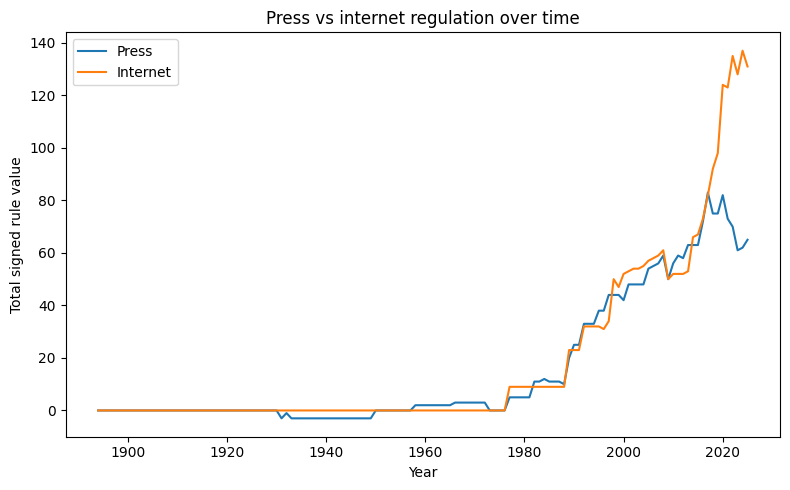

In [19]:
press_combined_cols = press_cols + press_gov_cols
internet_combined_cols = internet_cols + im_cols

yearly_combined_counts = pd.DataFrame({
    "year": df["year"],
    "press_total": df[press_combined_cols].fillna(0).sum(axis=1),
    "internet_total": df[internet_combined_cols].fillna(0).sum(axis=1)
})

yearly_combined_counts = (
    yearly_combined_counts.groupby("year")[["press_total", "internet_total"]]
    .sum()
    .reset_index()
)

plt.figure(figsize=(8, 5))
plt.plot(yearly_combined_counts["year"], yearly_combined_counts["press_total"], label="Press")
plt.plot(yearly_combined_counts["year"], yearly_combined_counts["internet_total"], label="Internet")
plt.xlabel("Year")
plt.ylabel("Total signed rule value")
plt.title("Press vs internet regulation over time")
plt.legend()
plt.tight_layout()
plt.show()

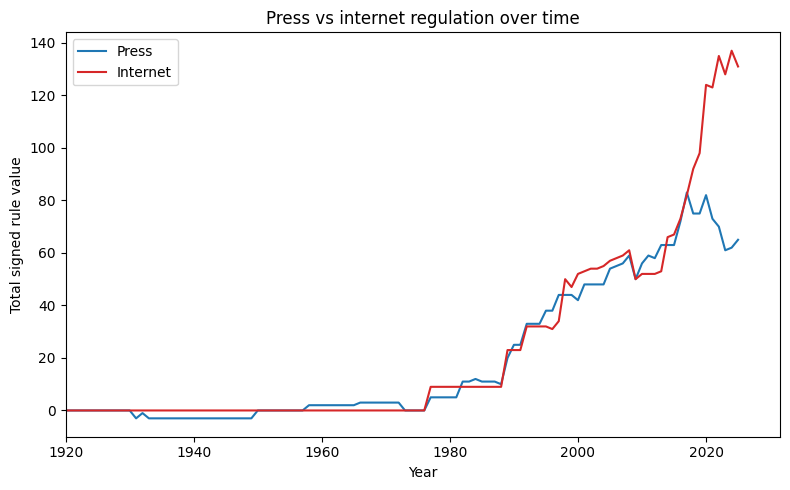

In [20]:
press_combined_cols = press_cols + press_gov_cols
internet_combined_cols = internet_cols + im_cols

yearly_combined_counts = pd.DataFrame({
    "year": df["year"],
    "press_total": df[press_combined_cols].fillna(0).sum(axis=1),
    "internet_total": df[internet_combined_cols].fillna(0).sum(axis=1)
})

yearly_combined_counts = (
    yearly_combined_counts.groupby("year")[["press_total", "internet_total"]]
    .sum()
    .reset_index()
)

plt.figure(figsize=(8, 5))
plt.plot(
    yearly_combined_counts["year"],
    yearly_combined_counts["press_total"],
    label="Press",
    color="#1f77b4"
)
plt.plot(
    yearly_combined_counts["year"],
    yearly_combined_counts["internet_total"],
    label="Internet",
    color="#d62728"
)
plt.xlim(left=1920)
plt.xlabel("Year")
plt.ylabel("Total signed rule value")
plt.title("Press vs internet regulation over time")
plt.legend()
plt.tight_layout()
plt.show()

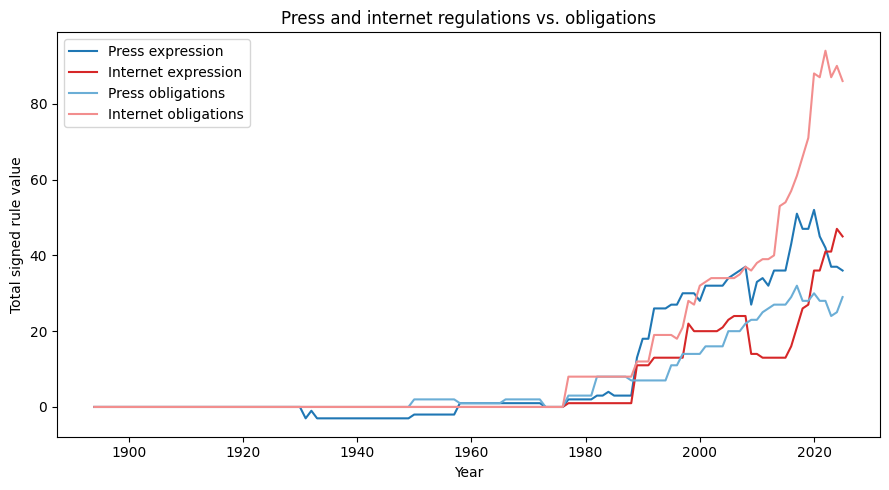

In [21]:
yearly_family_counts = pd.DataFrame({
    "year": df["year"],
    "P_total": df[press_cols].fillna(0).sum(axis=1),
    "I_total": df[internet_cols].fillna(0).sum(axis=1),
    "PRESS_total": df[press_gov_cols].fillna(0).sum(axis=1),
    "IM_total": df[im_cols].fillna(0).sum(axis=1)
})

yearly_family_counts = (
    yearly_family_counts.groupby("year")[["P_total", "I_total", "PRESS_total", "IM_total"]]
    .sum()
    .reset_index()
)

plt.figure(figsize=(9, 5))
plt.plot(
    yearly_family_counts["year"],
    yearly_family_counts["P_total"],
    label="Press expression",
    color="#1f77b4"
)
plt.plot(
    yearly_family_counts["year"],
    yearly_family_counts["I_total"],
    label="Internet expression",
    color="#d62728"
)
plt.plot(
    yearly_family_counts["year"],
    yearly_family_counts["PRESS_total"],
    label="Press obligations",
    color="#6baed6"
)
plt.plot(
    yearly_family_counts["year"],
    yearly_family_counts["IM_total"],
    label="Internet obligations",
    color="#f28e8e"
)
plt.xlabel("Year")
plt.ylabel("Total signed rule value")
plt.title("Press and internet regulations vs. obligations")
plt.legend()
plt.tight_layout()
plt.show()

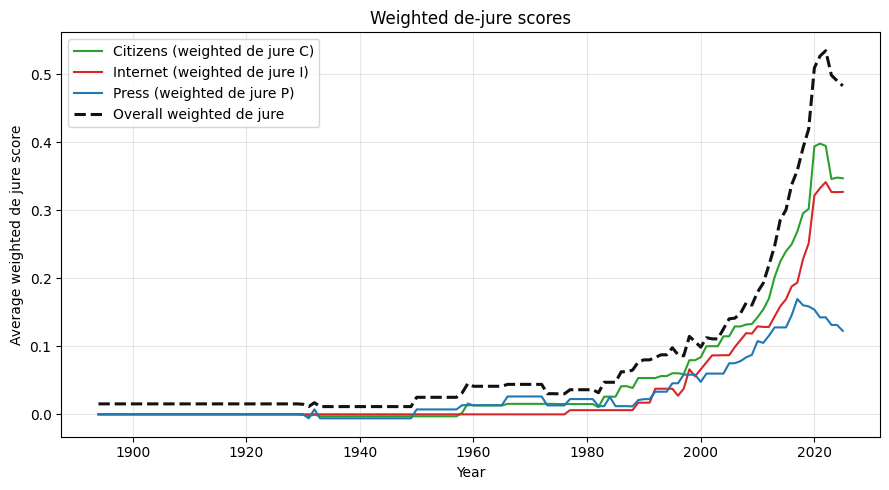

,year,weighted_de_jure_C,weighted_de_jure_I,weighted_de_jure_P,weighted_de_jure
0,1894,0.000000,0.000000,0.000000,0.015385
1,1895,0.000000,0.000000,0.000000,0.015385
2,1896,0.000000,0.000000,0.000000,0.015385
3,1897,0.000000,0.000000,0.000000,0.015385
4,1898,0.000000,0.000000,0.000000,0.015385
...,...,...,...,...,...
127,2021,0.397838,0.332418,0.142406,0.526598
128,2022,0.394419,0.341309,0.142619,0.534331
129,2023,0.345822,0.326779,0.131445,0.498215
130,2024,0.347931,0.326528,0.131283,0.490123


In [22]:
weighted_de_jure_trends = (
    df.groupby("year")[[
        "weighted_de_jure_C",
        "weighted_de_jure_I",
        "weighted_de_jure_P",
        "weighted_de_jure"
    ]]
    .mean()
    .reset_index()
)

plt.figure(figsize=(9, 5))
plt.plot(
    weighted_de_jure_trends["year"],
    weighted_de_jure_trends["weighted_de_jure_C"],
    label="Citizens (weighted de jure C)",
    color="#2ca02c"
)
plt.plot(
    weighted_de_jure_trends["year"],
    weighted_de_jure_trends["weighted_de_jure_I"],
    label="Internet (weighted de jure I)",
    color="#d62728"
)
plt.plot(
    weighted_de_jure_trends["year"],
    weighted_de_jure_trends["weighted_de_jure_P"],
    label="Press (weighted de jure P)",
    color="#1f77b4"
)
plt.plot(
    weighted_de_jure_trends["year"],
    weighted_de_jure_trends["weighted_de_jure"],
    label="Overall weighted de jure",
    color="#111111",
    linewidth=2.2,
    linestyle="--"
)
plt.xlabel("Year")
plt.ylabel("Average weighted de jure score")
plt.title("Weighted de-jure scores")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

weighted_de_jure_trends

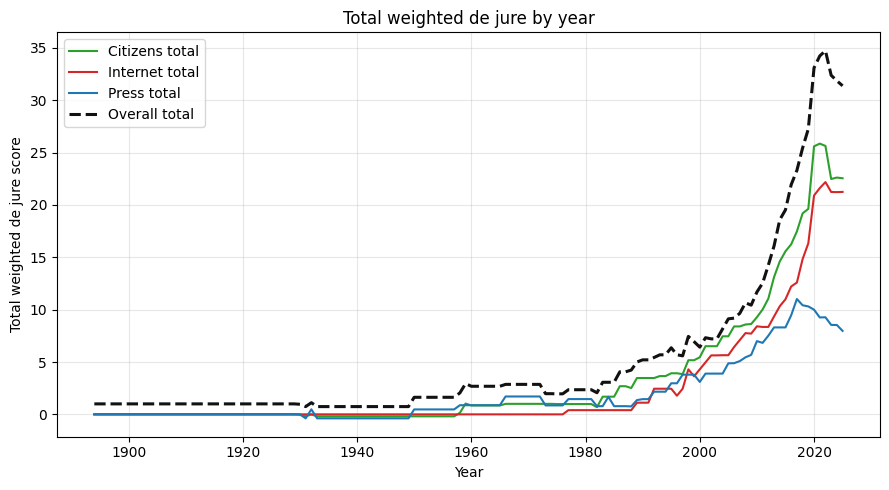

,year,weighted_de_jure_C,weighted_de_jure_I,weighted_de_jure_P,weighted_de_jure
0,1894,0.000000,0.000000,0.000000,1.000000
1,1895,0.000000,0.000000,0.000000,1.000000
2,1896,0.000000,0.000000,0.000000,1.000000
3,1897,0.000000,0.000000,0.000000,1.000000
4,1898,0.000000,0.000000,0.000000,1.000000
...,...,...,...,...,...
127,2021,25.859456,21.607191,9.256364,34.228868
128,2022,25.637233,22.185064,9.270253,34.731484
129,2023,22.478419,21.240619,8.543900,32.384005
130,2024,22.615502,21.224345,8.533406,31.857971


In [23]:
weighted_de_jure_totals = (
    df.groupby("year")[[
        "weighted_de_jure_C",
        "weighted_de_jure_I",
        "weighted_de_jure_P",
        "weighted_de_jure"
    ]]
    .sum()
    .reset_index()
)

plt.figure(figsize=(9, 5))
plt.plot(
    weighted_de_jure_totals["year"],
    weighted_de_jure_totals["weighted_de_jure_C"],
    label="Citizens total",
    color="#2ca02c"
)
plt.plot(
    weighted_de_jure_totals["year"],
    weighted_de_jure_totals["weighted_de_jure_I"],
    label="Internet total",
    color="#d62728"
)
plt.plot(
    weighted_de_jure_totals["year"],
    weighted_de_jure_totals["weighted_de_jure_P"],
    label="Press total",
    color="#1f77b4"
)
plt.plot(
    weighted_de_jure_totals["year"],
    weighted_de_jure_totals["weighted_de_jure"],
    label="Overall total",
    color="#111111",
    linewidth=2.2,
    linestyle="--"
)
plt.xlabel("Year")
plt.ylabel("Total weighted de jure score")
plt.title("Total weighted de jure by year")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

weighted_de_jure_totals

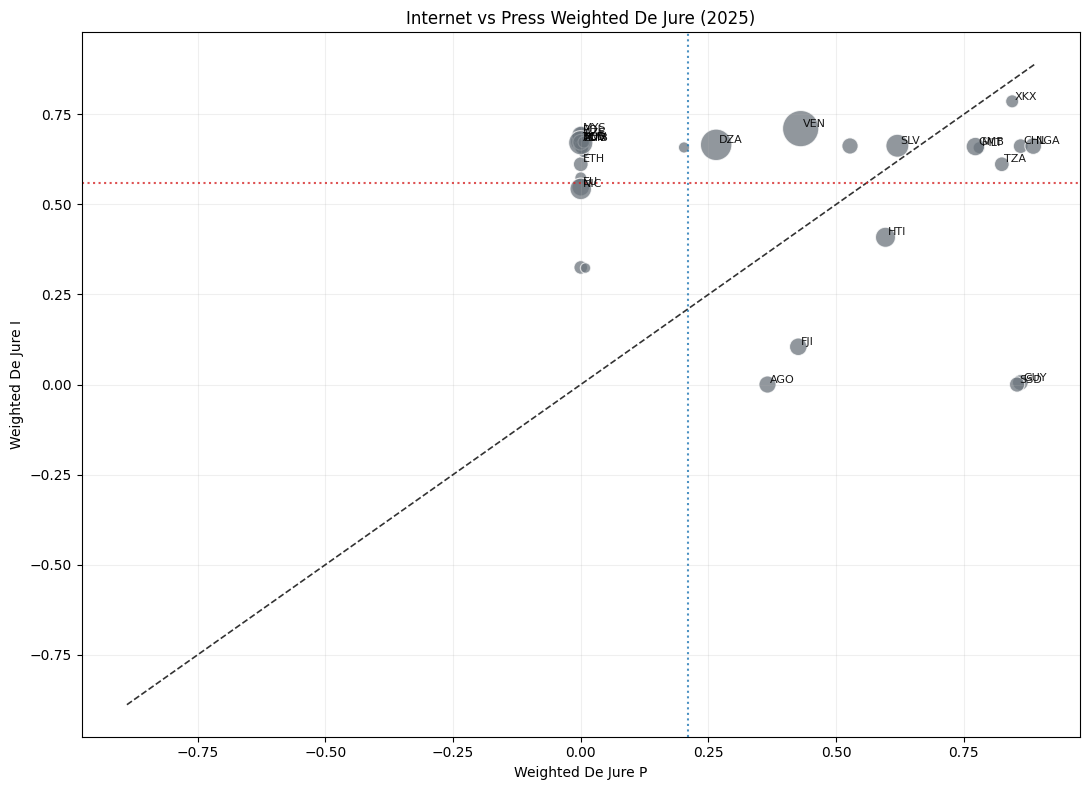

,COUNTRY,iso3,weighted_de_jure_I,weighted_de_jure_P,legal_rule_count_total,bubble_size,weighted_de_jure_P_jitter,weighted_de_jure_I_jitter,gap
8183,Venezuela,VEN,0.706349,0.434641,85,680,0.430733,0.710486,0.271709
395,Algeria,DZA,0.666667,0.256173,64,512,0.265187,0.665470,0.410494
8447,Zambia,ZMB,0.666667,-0.380952,38,304,0.000000,0.671247,1.047619
2243,El Salvador,SLV,0.666667,0.618056,34,272,0.620078,0.662901,0.048611
5147,Nicaragua,NIC,0.545455,0.000000,30,240,0.000000,0.543228,0.545455
3563,Hungary,HUN,0.666667,0.000000,27,216,0.000000,0.674563,0.666667
3299,Haiti,HTI,0.400000,0.603175,26,208,0.596811,0.408790,0.203175
7523,The Gambia,GMB,0.666667,0.763889,22,176,0.772867,0.660641,0.097222
5939,Poland,POL,0.691358,-0.888889,21,168,0.000000,0.692212,1.580247
2639,European Union,EU,0.547009,0.000000,20,160,0.000000,0.547943,0.547009


In [24]:
plot_year = 2025

scatter_df = (
    df.loc[df["year"] == plot_year, [
        "COUNTRY",
        "iso3",
        "weighted_de_jure_I",
        "weighted_de_jure_P",
        "legal_rule_count_total"
    ]]
    .dropna()
    .copy()
)

scatter_df = scatter_df[
    (scatter_df["weighted_de_jure_P"] > 0) |
    (scatter_df["weighted_de_jure_I"] > 0)
].copy()

scatter_df["bubble_size"] = scatter_df["legal_rule_count_total"] * 8

np.random.seed(42)
scatter_df["weighted_de_jure_P_jitter"] = (
    scatter_df["weighted_de_jure_P"] + np.random.uniform(-0.01, 0.01, len(scatter_df))
)
scatter_df["weighted_de_jure_I_jitter"] = (
    scatter_df["weighted_de_jure_I"] + np.random.uniform(-0.01, 0.01, len(scatter_df))
)
scatter_df["weighted_de_jure_P_jitter"] = scatter_df["weighted_de_jure_P_jitter"].clip(lower=0)
scatter_df["weighted_de_jure_I_jitter"] = scatter_df["weighted_de_jure_I_jitter"].clip(lower=0)

scatter_df["gap"] = (
    scatter_df["weighted_de_jure_I"] - scatter_df["weighted_de_jure_P"]
).abs()

label_df = pd.concat([
    scatter_df.nlargest(12, "legal_rule_count_total"),
    scatter_df.nlargest(10, "gap"),
    scatter_df.nlargest(10, "weighted_de_jure_I"),
    scatter_df.nlargest(10, "weighted_de_jure_P")
]).drop_duplicates(subset="iso3")

x_min = scatter_df["weighted_de_jure_P"].min()
x_max = scatter_df["weighted_de_jure_P"].max()
y_min = scatter_df["weighted_de_jure_I"].min()
y_max = scatter_df["weighted_de_jure_I"].max()
line_min = min(x_min, y_min)
line_max = max(x_max, y_max)

p_mean = scatter_df["weighted_de_jure_P"].mean()
i_mean = scatter_df["weighted_de_jure_I"].mean()

plt.figure(figsize=(11, 8))
plt.scatter(
    scatter_df["weighted_de_jure_P_jitter"],
    scatter_df["weighted_de_jure_I_jitter"],
    s=scatter_df["bubble_size"],
    color="#6c757d",
    alpha=0.75,
    edgecolor="white",
    linewidth=0.8
)

for _, row in label_df.iterrows():
    plt.text(
        row["weighted_de_jure_P_jitter"] + 0.005,
        row["weighted_de_jure_I_jitter"] + 0.005,
        row["iso3"],
        fontsize=8,
        alpha=0.9
    )

plt.plot(
    [line_min, line_max],
    [line_min, line_max],
    linestyle="--",
    color="black",
    linewidth=1.2,
    alpha=0.8
)

plt.axvline(p_mean, linestyle=":", color="#1f77b4", alpha=0.8)
plt.axhline(i_mean, linestyle=":", color="#d62728", alpha=0.8)

plt.xlabel("Weighted De Jure P")
plt.ylabel("Weighted De Jure I")
plt.title(f"Internet vs Press Weighted De Jure ({plot_year})")
plt.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

scatter_df.sort_values("legal_rule_count_total", ascending=False)

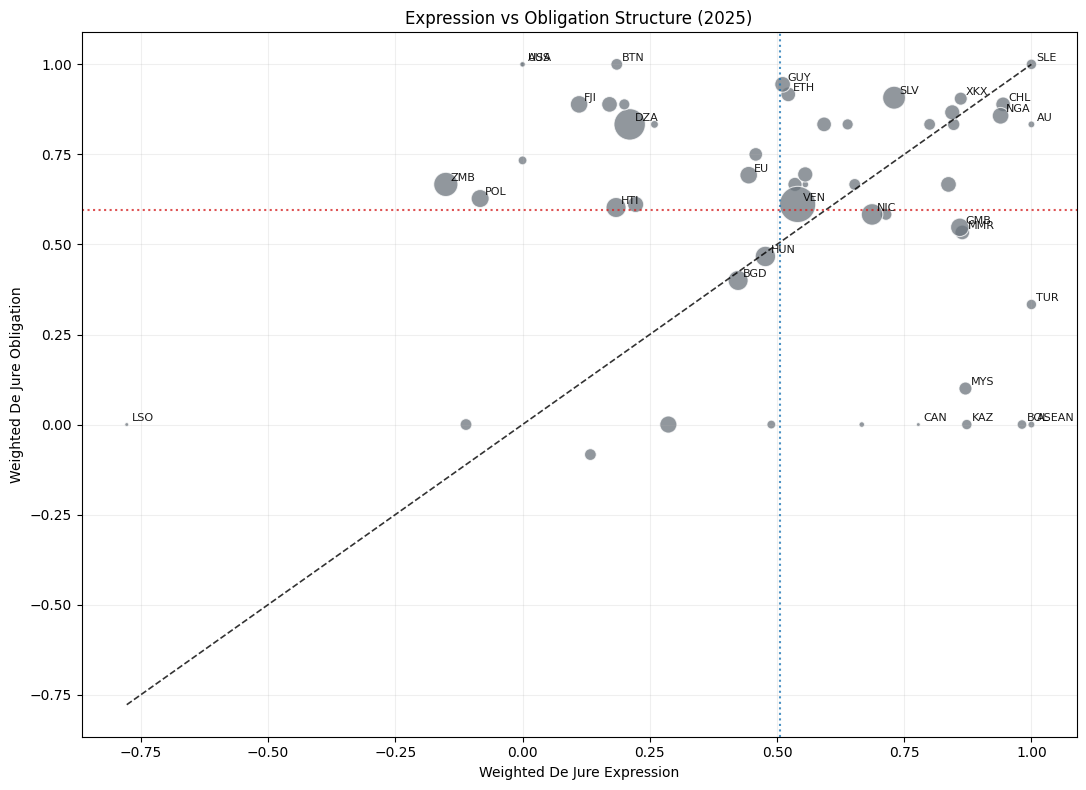

,COUNTRY,iso3,weighted_de_jure_EXPRESSION,weighted_de_jure_OBLIGATION,legal_rule_count_total,bubble_size,balance_gap
8183,Venezuela,VEN,0.540598,0.611111,85,680,0.070513
395,Algeria,DZA,0.210526,0.833333,64,512,0.622807
8447,Zambia,ZMB,-0.150794,0.666667,38,304,0.817460
2243,El Salvador,SLV,0.730159,0.907407,34,272,0.177249
5147,Nicaragua,NIC,0.686869,0.583333,30,240,0.103535
3563,Hungary,HUN,0.477273,0.466667,27,216,0.010606
923,Bangladesh,BGD,0.423611,0.400000,26,208,0.023611
3299,Haiti,HTI,0.183761,0.602564,26,208,0.418803
7523,The Gambia,GMB,0.859259,0.547619,22,176,0.311640
5939,Poland,POL,-0.083333,0.627451,21,168,0.710784


In [32]:
plot_year = 2025

structure_df = (
    df.loc[df["year"] == plot_year, [
        "COUNTRY",
        "iso3",
        "weighted_de_jure_EXPRESSION",
        "weighted_de_jure_OBLIGATION",
        "legal_rule_count_total"
    ]]
    .dropna()
    .copy()
)

structure_df = structure_df[
    (structure_df["weighted_de_jure_EXPRESSION"] != 0) |
    (structure_df["weighted_de_jure_OBLIGATION"] != 0)
].copy()

structure_df["bubble_size"] = structure_df["legal_rule_count_total"] * 8
structure_df["balance_gap"] = (
    structure_df["weighted_de_jure_OBLIGATION"] - structure_df["weighted_de_jure_EXPRESSION"]
).abs()

label_df = pd.concat([
    structure_df.nlargest(12, "legal_rule_count_total"),
    structure_df.nlargest(10, "balance_gap"),
    structure_df.nlargest(10, "weighted_de_jure_EXPRESSION"),
    structure_df.nlargest(10, "weighted_de_jure_OBLIGATION")
]).drop_duplicates(subset="iso3")

x_mean = structure_df["weighted_de_jure_EXPRESSION"].mean()
y_mean = structure_df["weighted_de_jure_OBLIGATION"].mean()
line_min = min(
    structure_df["weighted_de_jure_EXPRESSION"].min(),
    structure_df["weighted_de_jure_OBLIGATION"].min()
)
line_max = max(
    structure_df["weighted_de_jure_EXPRESSION"].max(),
    structure_df["weighted_de_jure_OBLIGATION"].max()
)

plt.figure(figsize=(11, 8))
plt.scatter(
    structure_df["weighted_de_jure_EXPRESSION"],
    structure_df["weighted_de_jure_OBLIGATION"],
    s=structure_df["bubble_size"],
    color="#6c757d",
    alpha=0.75,
    edgecolor="white",
    linewidth=0.8
)

for _, row in label_df.iterrows():
    plt.text(
        row["weighted_de_jure_EXPRESSION"] + 0.01,
        row["weighted_de_jure_OBLIGATION"] + 0.01,
        row["iso3"],
        fontsize=8,
        alpha=0.9
    )

plt.plot(
    [line_min, line_max],
    [line_min, line_max],
    linestyle="--",
    color="black",
    linewidth=1.2,
    alpha=0.8
)
plt.axvline(x_mean, linestyle=":", color="#1f77b4", alpha=0.8)
plt.axhline(y_mean, linestyle=":", color="#d62728", alpha=0.8)

plt.xlabel("Weighted De Jure Expression")
plt.ylabel("Weighted De Jure Obligation")
plt.title(f"Expression vs Obligation Structure ({plot_year})")
plt.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

structure_df.sort_values("legal_rule_count_total", ascending=False)